In [2]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

false

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [ ]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)
dt = 0.1       
T_max = 3     
cutoff = 1e-12
maxdim = 200

# Physical indices
sites = siteinds("S=1/2", N)

In [4]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_WII(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    
    I2 = ComplexF64[1 0; 0 1]
    Z  = ComplexF64[1 0; 0 -1]
    X  = ComplexF64[0 1; 1 0]
    O2 = ComplexF64[0 0; 0 0]
    
    # Define Hamiltonian Blocks
    D_op = -lambda .* X
    C_op = [Z, O2, X]
    B_op = [-Z, -p .* Z, -p * lambda .* X]
    
    A_op = fill(O2, 3, 3)
    A_op[1, 2] = I2
    
    tau = -im * dt
    
    W_II = Matrix{Matrix{ComplexF64}}(undef, 4, 4)  # matrix 4x4 of matrices 2x2 (8x8 total)
    
    # we loop over all combinations of a and a_bar (from 1 to 3 possible states) 
    # to construct the 8x8 matrix M that encodes the transition rules of the Zaletel MPO construction
    for a in 1:3
        for a_bar in 1:3
            M = zeros(ComplexF64, 8, 8)
            
            function set_M!(i, j, mat)
                M[2*(i-1)+1 : 2*i, 2*(j-1)+1 : 2*j] .= mat
            end
            
            # Zaletel 8x8 Boson transitions
            set_M!(1, 1, tau .* D_op)
            
            set_M!(2, 1, sqrt(tau) .* B_op[a])
            set_M!(2, 2, tau .* D_op)
            
            set_M!(3, 1, sqrt(tau) .* C_op[a_bar])
            set_M!(3, 3, tau .* D_op)
            
            set_M!(4, 1, A_op[a, a_bar])
            set_M!(4, 2, sqrt(tau) .* C_op[a_bar])
            set_M!(4, 3, sqrt(tau) .* B_op[a])
            set_M!(4, 4, tau .* D_op)
            
    
            E = exp(M)
            
            
            W_II[1, 1] = E[1:2, 1:2]                 
            W_II[1+a, 1] = E[3:4, 1:2]               
            W_II[1, 1+a_bar] = E[5:6, 1:2]           
            W_II[1+a, 1+a_bar] = E[7:8, 1:2]         
        end
    end
    
    links = [Index(4, "Link,l=$i") for i in 1:N-1]
    U_dt = MPO(sites)
    
    for i in 1:N
        s = sites[i]
        
        if i == 1
            W = ITensor(ComplexF64, links[1], s', s)
            for col in 1:4, s1 in 1:2, s2 in 1:2
                W[links[1]=>col, s'=>s1, s=>s2] = W_II[1, col][s1, s2]
            end
            U_dt[i] = W
        elseif i == N
            W = ITensor(ComplexF64, links[i-1], s', s)
            for row in 1:4, s1 in 1:2, s2 in 1:2
                W[links[i-1]=>row, s'=>s1, s=>s2] = W_II[row, 1][s1, s2]
            end
            U_dt[i] = W
        else
            W = ITensor(ComplexF64, links[i-1], links[i], s', s)
            for row in 1:4, col in 1:4, s1 in 1:2, s2 in 1:2
                W[links[i-1]=>row, links[i]=>col, s'=>s1, s=>s2] = W_II[row, col][s1, s2]
            end
            U_dt[i] = W
        end
    end
    
    return U_dt
end

expH_alcaraz_WII (generic function with 1 method)

In [5]:
function compute_alcaraz_entropies(
    mpo_generator::Function, p::Float64; Tmin::Int, Tmax::Int, dt::Float64=0.05, lambda::Float64=1.0, 
    cutoff::Float64=1e-12, maxdim::Int=256, 
    alg="RTM", Tstep::Int=1, eps_converged::Float64=1e-8
    )

    s = Index(2, "S=1/2")
    init_state = up_state
    
    mp_alcaraz = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, 0.0im, mpo_generator, mp_alcaraz, 0, init_state)    
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 3000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    times = Float64[]
    vn_R = Float64[]
    vn_L = Float64[]
    pseudo_vn = ComplexF64[]
    pseudo_r2 = ComplexF64[]


    for Nsteps in Tmin:Tstep:Tmax
        time_sites = addtags(siteinds(4, Nsteps), "time")
        
        # Transfer Matrix MPO 
        mpo = fw_tMPO(b, time_sites; tr=tp.bl)
        
        # Initial boundary MPS (guess) to start the power method
        start_mps = fw_tMPS(b, time_sites; tr=tp.bl, LR=:right)
        
        # Compute the left and right dominant eigenvectors of the transfer matrix MPO using the power method
        psi_L, psi_R, _ = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

        # Normalization
        norm = overlap_noconj(psi_L, psi_R)
        psi_L = psi_L / sqrt(norm)
        psi_R = psi_R / sqrt(norm)
        
        # Standard VN entropy at the center cut of the time string
        center_bond = div(Nsteps, 2)
        push!(vn_R, real(vn_entanglement_entropy(psi_R)[center_bond]))
        push!(vn_L, real(vn_entanglement_entropy(psi_L)[center_bond]))

        # Generalized VN and Renyi-2 pseudo-entropies
        p_vn = ITransverse.generalized_svd_vn_entropy(psi_L, psi_R)
        p_r2 = ITransverse.gen_renyi2(psi_L, psi_R)
        
        push!(pseudo_vn, p_vn[center_bond])
        push!(pseudo_r2, p_r2[center_bond])
        
        push!(times, Nsteps * dt)
    end
    
    return times, vn_R, vn_L, pseudo_vn, pseudo_r2
end

compute_alcaraz_entropies (generic function with 1 method)

In [18]:
function compute_entropy_profile(mpo_generator, p::Float64, target_T::Float64; dt::Float64=0.05, lambda::Float64=1.0, cutoff::Float64=1e-12, maxdim::Int=256, nbeta::Int=4)
    # Loschmidt Geometry
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta # we add the imaginary time steps to the total length of the time string
    dbeta = im * dt

    # Physical Hilbert space
    s = Index(2, "S=1/2")
    init_state = up_state
    
    mp_model = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, dbeta, mpo_generator, mp_model, nbeta, init_state)    
    b = FwtMPOBlocks(tp)
    
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg="naiveRTM"), 
        opt_method = :nosym,
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = 1e-6, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Loschmidt Framework: Dimension 2 ("S=1/2"), unfolded
    time_sites = addtags(siteinds(4, Nsteps), "time")    
    mpo = fw_tMPO(b, time_sites; tr=tp.bl)
    start_mps = fw_tMPS(b, time_sites; tr=tp.bl, LR=:right)
    
    # Asymmetric Power Method
    psi_L, psi_R, _ = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalization (regular)
    norm_VN_L = inner(psi_L, psi_L)
    psi_L_VN = psi_L / sqrt(norm_VN_L)
    norm_VN_R = inner(psi_R, psi_R)
    psi_R_VN = psi_R / sqrt(norm_VN_R)

    # Normalization (RTM)
    norm = overlap_noconj(psi_L, psi_R)
    psi_L_pseudo = psi_L / sqrt(norm)
    psi_R_pseudo = psi_R / sqrt(norm)
    
    # Calculate raw entropies
    vR_raw = real.(vn_entanglement_entropy(psi_R_VN))
    vL_raw = real.(vn_entanglement_entropy(psi_L_VN))
    pVN_raw = real.(ITransverse.generalized_svd_vn_entropy(psi_L_pseudo, psi_R_pseudo))
    pR2_raw = real.(ITransverse.gen_renyi2(psi_L_pseudo, psi_R_pseudo))

    # Dynamically find the length of the internal physical bonds
    min_len = minimum([length(vR_raw), length(vL_raw), length(pVN_raw), length(pR2_raw)])
    
    # Helper to symmetrically drop the trivial edges (0 at start, N at end) 
    function center_crop(arr, target)
        drop = length(arr) - target
        drop_left = div(drop, 2)
        return arr[(1 + drop_left) : (end - (drop - drop_left))]
    end

    vn_R_profile = center_crop(vR_raw, min_len)
    vn_L_profile = center_crop(vL_raw, min_len)
    pseudo_vn_profile = center_crop(pVN_raw, min_len)
    pseudo_r2_profile = center_crop(pR2_raw, min_len)

    bonds = 1:min_len
    
    return bonds, vn_R_profile, vn_L_profile, pseudo_vn_profile, pseudo_r2_profile
end


function plot_entropy_profiles(mpo_generator, p::Float64, target_times::Vector{Float64}; dt::Float64=0.05, lambda::Float64=1.0, cutoff::Float64=1e-12, maxdim::Int=256)
    plots_array = []

    @showprogress for (i, T) in enumerate(target_times)
        bonds, vR, vL, pVN, pR2 = compute_entropy_profile(
            mpo_generator, p, T; dt=dt, maxdim=maxdim, lambda=lambda, cutoff=cutoff
        )
        
        show_legend = (i == 1)
        
        p_sub = plot(
            bonds, vR, 
            label=show_legend ? "VN (|R>)" : "", 
            lw=2, 
            title="T = $(round(T, digits=2))", 
            titlefontsize=10,
            legend=show_legend ? :topright : false
        )
        plot!(p_sub, bonds, vL, label=show_legend ? "VN (<L|)" : "", lw=2, ls=:dash)
        plot!(p_sub, bonds, pVN, label=show_legend ? "Pseudo-VN" : "", lw=2)
        plot!(p_sub, bonds, pR2, label=show_legend ? "Pseudo-Rényi 2" : "", lw=2, ls=:dot)
        
        push!(plots_array, p_sub)
    end

    # Dynamically calculate grid dimensions (e.g., 4 columns)
    n_plots = length(plots_array)
    cols = 4
    rows = ceil(Int, n_plots / cols)

    # Combine all subplots into a responsive grid
    final_plot = plot(
        plots_array..., 
        layout=(rows, cols), 
        size=(1200, 250 * rows), # Adjust height dynamically based on rows
        margin=3Plots.mm
    )
    display(final_plot)
end 

plot_entropy_profiles (generic function with 1 method)

[PM LR|naiveRTM|nosym] L=60, cutoff=1.0e-12, maxdim=500, normalize=overlap)  72%  ETA: 0:01:08 (80.82 ms/it)
   Info: [2163]  chi=13 | ds=1.1389579939583006e-5 | <R|Rprev> = -6.729657989756887e-8┌ Warning: PM Stuck after 201/2164 steps | ds=8.840729482900711e-6 | chi=13)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


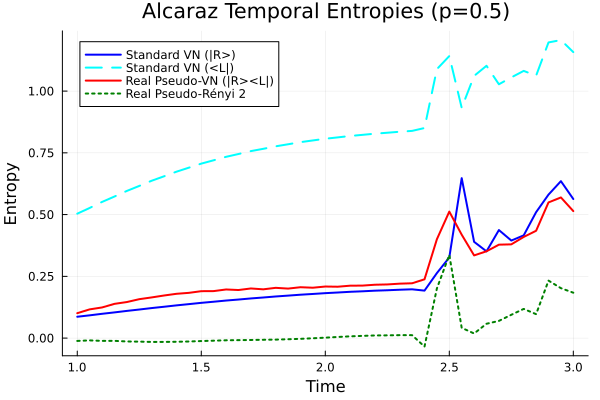

In [12]:
# Run simulation 1st ONE
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=20, Tmax=60, dt=0.05, cutoff=1e-12, maxdim=500, alg="naiveRTM", Tstep=1, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|naiveRTM|nosym] L=300, cutoff=1.0e-12, maxdim=500, normalize=overlap)  20%  ETA: 0:13:47 ( 0.35  s/it)
   Info: [615]  chi=11 | ds=7.994760876717244e-5 | <R|Rprev> = -1.1761472041404986e-6┌ Warning: PM Stuck after 201/616 steps | ds=8.000636314352272e-5 | chi=11)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


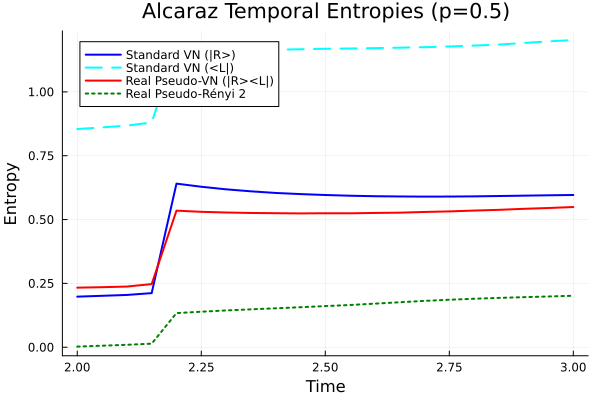

In [7]:
# Run simulation 1st ONE
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=200, Tmax=300, dt=0.01, cutoff=1e-12, maxdim=500, alg="naiveRTM", Tstep=5, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|naiveRTM|nosym] L=60, cutoff=1.0e-12, maxdim=500, normalize=overlap)   7%  ETA: 0:01:49 (39.00 ms/it)
   Info: [200]  chi=6 | ds=3.7533702395009527e-6 | <R|Rprev> = -1.7741771015285698e-12[ Info: PM Converged after 203 steps | ds=9.86331640473459e-7 | chi=6)


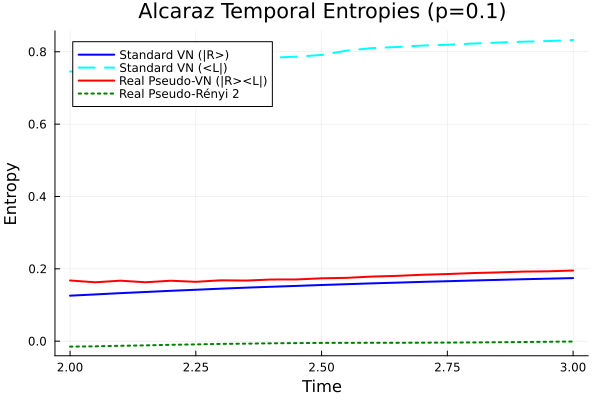

In [ ]:
# Run simulation 1st ONE
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.1; Tmin=20, Tmax=60, dt=0.05, cutoff=1e-12, maxdim=500, alg="naiveRTM", Tstep=1, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.1)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|naiveRTM|nosym] L=70, cutoff=1.0e-12, maxdim=256, normalize=overlap)  66%  ETA: 0:02:49 ( 0.10  s/it)
   Info: [3313]  chi=14 | ds=3.309440035903499e-8 | <R|Rprev> = -4.7580986769649563e-17[ Info: PM Converged after 3315 steps | ds=8.383195804206878e-9 | chi=14)
Progress: 100%|█████████████████████████████████████████| Time: 0:08:58


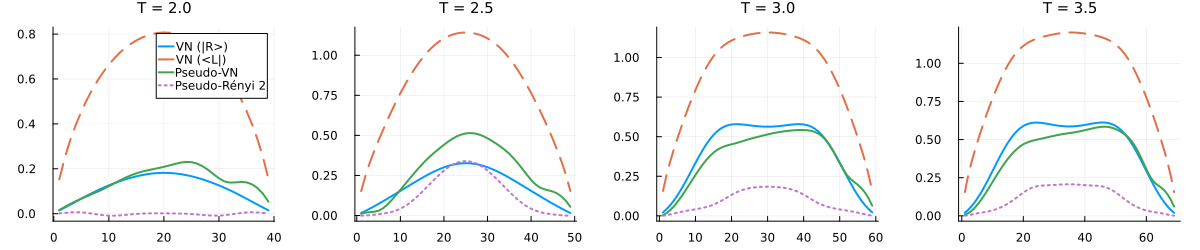

In [8]:
target_times = collect(2.0:0.5:3.5)

plot_entropy_profiles(
    expH_alcaraz_WII, 
    0.5,           
    target_times; 
    dt=0.05, 
    lambda=1.0, 
    cutoff=1e-12,
    maxdim=256     
)

Let's now compare it with the ising murg MPO generator by changing the mpo constructor and also the space of the temporal MPOs (which must match the dimensions of the MPO generator of our model; for ising it is 2, for our Alcaraz model it is 4).

Remember that we are rotating the tensor network 90 degrees, treating the time steps as the sites of our 1D MPS, and the space as the direction of the transfer matrix.

In this rotated geometry, the "physical" indices of our MPS are actually the bond indices of our original Hamiltonian MPO.

In [9]:
function compute_entropy_profile_ising(mpo_generator, p::Float64, target_T::Float64; dt::Float64=0.05, lambda::Float64=1.0, cutoff::Float64=1e-12, maxdim::Int=256, nbeta::Int=4)
    # Loschmidt Geometry
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta # we add the imaginary time steps to the total length of the time string
    dbeta = im * dt

    # Physical Hilbert space
    s = Index(2, "S=1/2")
    init_state = up_state
    
    mp_model = IsingParams(1.0, 1.0, 0.0)
    tp = tMPOParams(dt, dbeta, mpo_generator, mp_model, nbeta, init_state)    
    b = FwtMPOBlocks(tp)
    
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg="naiveRTM"), 
        opt_method = :nosym,
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = 1e-6, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Loschmidt Framework: Dimension 2 ("S=1/2"), unfolded
    time_sites = addtags(siteinds(2, Nsteps), "time")    
    mpo = fw_tMPO(b, time_sites; tr=tp.bl)
    start_mps = fw_tMPS(b, time_sites; tr=tp.bl, LR=:right)
    
    # Asymmetric Power Method
    psi_L, psi_R, _ = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalization (regular)
    norm_VN_L = inner(psi_L, psi_L)
    psi_L_VN = psi_L / sqrt(norm_VN_L)
    norm_VN_R = inner(psi_R, psi_R)
    psi_R_VN = psi_R / sqrt(norm_VN_R)

    # Normalization (RTM)
    norm = overlap_noconj(psi_L, psi_R)
    psi_L_pseudo = psi_L / sqrt(norm)
    psi_R_pseudo = psi_R / sqrt(norm)
    
    # Calculate raw entropies
    vR_raw = real.(vn_entanglement_entropy(psi_R_VN))
    vL_raw = real.(vn_entanglement_entropy(psi_L_VN))
    pVN_raw = real.(ITransverse.generalized_svd_vn_entropy(psi_L_pseudo, psi_R_pseudo))
    pR2_raw = real.(ITransverse.gen_renyi2(psi_L_pseudo, psi_R_pseudo))

    # Dynamically find the length of the internal physical bonds
    min_len = minimum([length(vR_raw), length(vL_raw), length(pVN_raw), length(pR2_raw)])
    
    # Helper to symmetrically drop the trivial edges (0 at start, N at end) 
    function center_crop(arr, target)
        drop = length(arr) - target
        drop_left = div(drop, 2)
        return arr[(1 + drop_left) : (end - (drop - drop_left))]
    end

    vn_R_profile = center_crop(vR_raw, min_len)
    vn_L_profile = center_crop(vL_raw, min_len)
    pseudo_vn_profile = center_crop(pVN_raw, min_len)
    pseudo_r2_profile = center_crop(pR2_raw, min_len)

    bonds = 1:min_len
    
    return bonds, vn_R_profile, vn_L_profile, pseudo_vn_profile, pseudo_r2_profile
end


function plot_entropy_profiles_ising(mpo_generator, p::Float64, target_times::Vector{Float64}; dt::Float64=0.05, lambda::Float64=1.0, cutoff::Float64=1e-12, maxdim::Int=256)
    plots_array = []

    @showprogress for (i, T) in enumerate(target_times)
        bonds, vR, vL, pVN, pR2 = compute_entropy_profile_ising(
            mpo_generator, p, T; dt=dt, maxdim=maxdim, lambda=lambda, cutoff=cutoff
        )
        
        show_legend = (i == 1)
        
        p_sub = plot(
            bonds, vR, 
            label=show_legend ? "VN (|R>)" : "", 
            lw=2, 
            title="T = $(round(T, digits=2))", 
            titlefontsize=10,
            legend=show_legend ? :topright : false
        )
        plot!(p_sub, bonds, vL, label=show_legend ? "VN (<L|)" : "", lw=2, ls=:dash)
        plot!(p_sub, bonds, pVN, label=show_legend ? "Pseudo-VN" : "", lw=2)
        plot!(p_sub, bonds, pR2, label=show_legend ? "Pseudo-Rényi 2" : "", lw=2, ls=:dot)
        
        push!(plots_array, p_sub)
    end

    # Dynamically calculate grid dimensions (e.g., 4 columns)
    n_plots = length(plots_array)
    cols = 4
    rows = ceil(Int, n_plots / cols)

    # Combine all subplots into a responsive grid
    final_plot = plot(
        plots_array..., 
        layout=(rows, cols), 
        size=(1200, 250 * rows), # Adjust height dynamically based on rows
        margin=3Plots.mm
    )
    display(final_plot)
end 

plot_entropy_profiles_ising (generic function with 1 method)

[PM LR|naiveRTM|nosym] L=704, cutoff=1.0e-12, maxdim=256, normalize=overlap)   3%  ETA: 0:35:51 ( 0.45  s/it)
   Info: [171]  chi=6 | ds=2.6039499833041546e-6 | <R|Rprev> = -2.2041554187895492e-14[ Info: PM Converged after 172 steps | ds=7.371273396117317e-7 | chi=6)
Progress: 100%|█████████████████████████████████████████| Time: 0:02:46


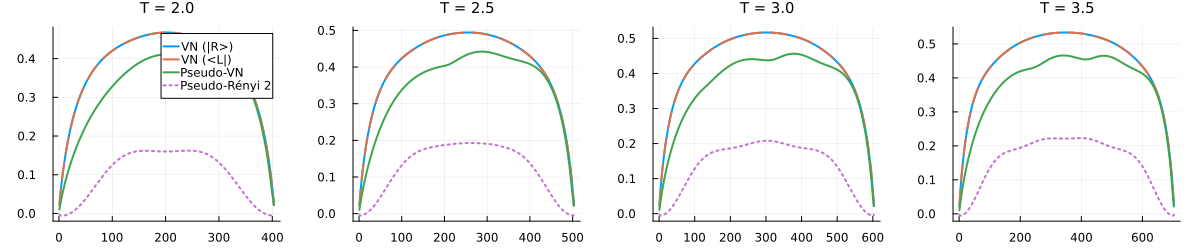

In [12]:
target_times = collect(2.0:0.5:3.5) 

plot_entropy_profiles_ising(
    expH_ising_murg,
    0.0,
    target_times; 
    dt=0.005, 
    lambda=1.0, 
    cutoff=1e-12,     
    maxdim=256       
)

NOTE: we are going to forger about the pseudo VN entropy cause in a not symmetric case (where L and R are not symm), we cannot compute (in the ising case we could do it cause everything was symmetric)

[PM LR|naiveRTM|nosym] L=3500, cutoff=1.0e-12, maxdim=256, normalize=overlap)   5%  ETA: 2:57:18 ( 2.25  s/it)
   Info: [268]  chi=4 | ds=0.002318638480694357 | <R|Rprev> = -2.4196030907998838e-6┌ Warning: norm² is 3180.608723917407 + 2.8421709430404007e-11im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/2UV9A/src/abstractmps.jl:1246
┌ Warning: PM Stuck after 201/269 steps | ds=0.0020962053783714074 | chi=5)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:19:20


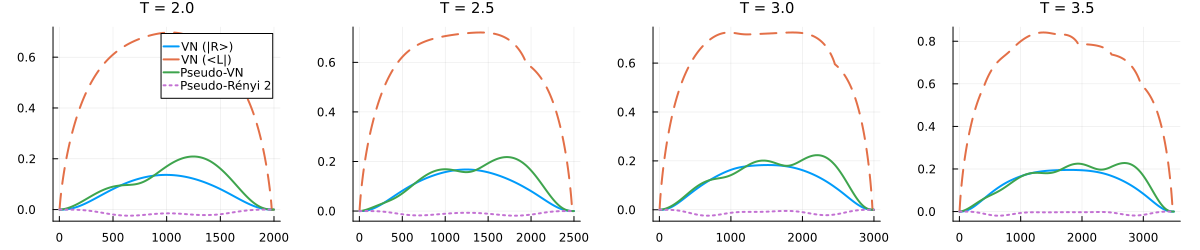

In [16]:
target_times = collect(2.0:0.5:3.5)

plot_entropy_profiles(
    expH_alcaraz_WII,  
    0.0,         
    target_times; 
    dt=0.001, 
    lambda=1.0, 
    cutoff=1e-12,   
    maxdim=256    
)

[PM LR|naiveRTM|nosym] L=700, cutoff=1.0e-12, maxdim=256, normalize=overlap)  33%  ETA: 0:48:01 ( 0.86  s/it)
   Info: [1638]  chi=12 | ds=0.0001094299160067369 | <R|Rprev> = -4.6951626123384724e-7┌ Warning: PM Stuck after 201/1639 steps | ds=0.0001431319057917102 | chi=12)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:39:42


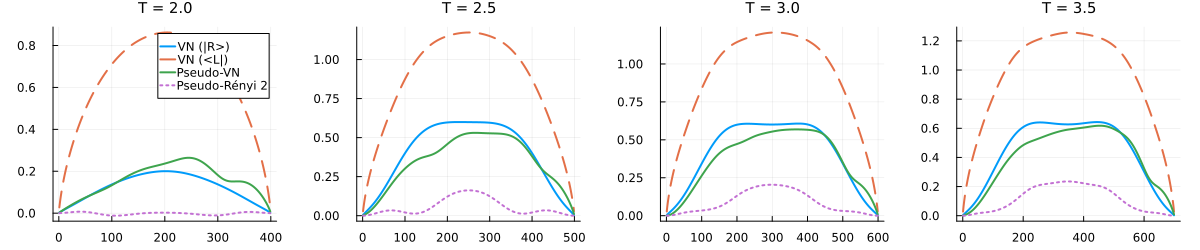

In [13]:
target_times = collect(2.0:0.5:3.5)

plot_entropy_profiles(
    expH_alcaraz_WII,  
    0.5,         
    target_times; 
    dt=0.005, 
    lambda=1.0, 
    cutoff=1e-12,   
    maxdim=256    
)

Entanglement Entropy is Gauge-Dependent in the spatial transfer matrix.

---

next plan:
- write in a second or fourth order the WII construction
- fix the assymetry by using the second order symmetrization of the WII construction